Temp (K)   | P_base (W/m²/sr)     | P_ext (W/m²/sr)      | Rel Error (%)  
---------------------------------------------------------------------------
300        | 1.416580e+02         | 1.455114e+02         | 2.6482         
3000       | 1.461934e+06         | 1.461990e+06         | 0.0038         
6000       | 2.339184e+07         | 2.339196e+07         | 0.0005         

--- Stefan-Boltzmann Verification ---
Fitted Exponent (n): 4.001694
Theoretical Exponent: 4.000000
Deviation: 0.001694

Intercept Check:
Fitted ln(C): -17.844384
Theoretical ln(sigma/pi): -17.830155
Calculated C from fit: 1.779436e-08
Theoretical C (sigma/pi): 1.804936e-08


/var/folders/j2/fdpp93ms7hsbgh7jlkqffz400000gq/T/ipykernel_46904/2064018090.py:55: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_base = np.trapz(planck_law(lam_base_m, T), lam_base_m)
/var/folders/j2/fdpp93ms7hsbgh7jlkqffz400000gq/T/ipykernel_46904/2064018090.py:58: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_ext = np.trapz(planck_law(lam_ext_m, T), lam_ext_m)


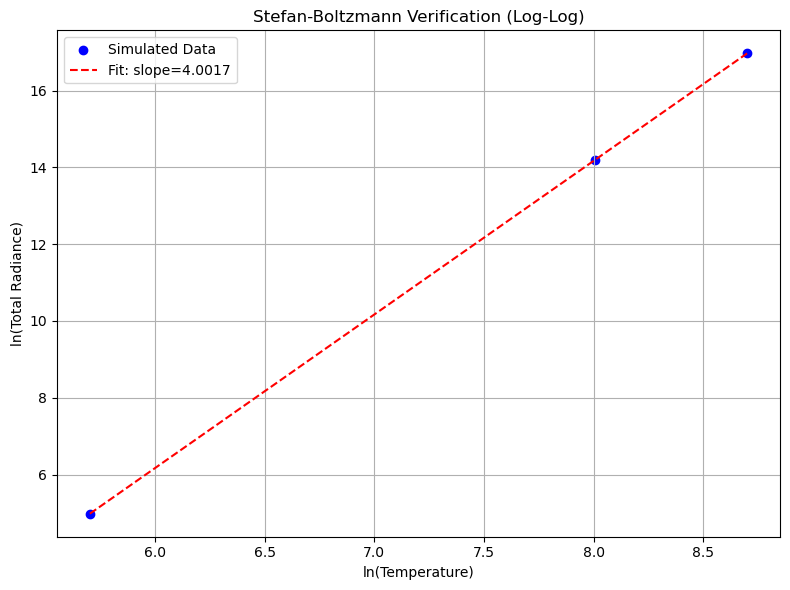

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Constants ---
h = 6.62607015e-34
c = 2.99792458e8
k_B = 1.380649e-23
b_wien = 2.897771955e-3
sigma = 5.670374419e-8 # Stefan-Boltzmann constant

def planck_law(wavelength_m, temperature_k):
    lam_arr = np.atleast_1d(wavelength_m).astype(float)
    if np.any(lam_arr <= 0): raise ValueError("Wavelengths must be positive.")
    if np.isscalar(temperature_k):
        if temperature_k <= 0: raise ValueError("Temperature must be positive.")
        T = temperature_k
    else:
        if np.any(temperature_k <= 0): raise ValueError("Temperatures must be positive.")
        T = temperature_k # Assuming scalar T for this function call context

    c1 = 2 * h * c**2
    c2 = h * c / k_B
    x = c2 / (lam_arr * T)
    
    overflow_mask = x > 700
    valid_mask = ~overflow_mask & np.isfinite(x)
    
    result = np.zeros_like(lam_arr)
    if np.any(valid_mask):
        exp_val = np.exp(x[valid_mask])
        result[valid_mask] = (c1 / lam_arr[valid_mask]**5) / (exp_val - 1.0)
        
    if np.isscalar(wavelength_m): return result[0]
    return result

# --- 1. Sensitivity Test Setup ---
temperatures = [300, 3000, 6000]

# Base Range: 0.1 to 50 um
lam_base_um = np.linspace(0.1, 50.0, 20000)
lam_base_m = lam_base_um * 1e-6

# Extended Range: 0.01 to 100 um (Higher resolution to capture tails)
# Using 100,000 points to ensure the long tail of 300K is resolved
lam_ext_um = np.linspace(0.01, 100.0, 100000)
lam_ext_m = lam_ext_um * 1e-6

print(f"{'Temp (K)':<10} | {'P_base (W/m²/sr)':<20} | {'P_ext (W/m²/sr)':<20} | {'Rel Error (%)':<15}")
print("-" * 75)

results_sb = []

for T in temperatures:
    # Integrate Base
    P_base = np.trapz(planck_law(lam_base_m, T), lam_base_m)
    
    # Integrate Extended
    P_ext = np.trapz(planck_law(lam_ext_m, T), lam_ext_m)
    
    # Relative Error (how much we missed in base)
    rel_error = (P_ext - P_base) / P_ext * 100
    
    print(f"{T:<10} | {P_base:<20.6e} | {P_ext:<20.6e} | {rel_error:<15.4f}")
    
    results_sb.append({'T': T, 'P': P_ext}) # Use extended as "truth"

# --- 2. Stefan-Boltzmann Verification ---
# Extract T and P
Ts = np.array([r['T'] for r in results_sb])
Ps = np.array([r['P'] for r in results_sb])

# Log-Log Fit: ln(P) = n * ln(T) + C
log_T = np.log(Ts)
log_P = np.log(Ps)

# Linear Regression
coeffs = np.polyfit(log_T, log_P, 1)
slope = coeffs[0]
intercept = coeffs[1]

# Theoretical Slope is 4
print(f"\n--- Stefan-Boltzmann Verification ---")
print(f"Fitted Exponent (n): {slope:.6f}")
print(f"Theoretical Exponent: 4.000000")
print(f"Deviation: {abs(slope - 4.0):.6f}")

# Check against sigma/pi
# P = (sigma/pi) * T^4
# So intercept should be ln(sigma/pi)
theoretical_intercept = np.log(sigma / np.pi)
print(f"\nIntercept Check:")
print(f"Fitted ln(C): {intercept:.6f}")
print(f"Theoretical ln(sigma/pi): {theoretical_intercept:.6f}")
print(f"Calculated C from fit: {np.exp(intercept):.6e}")
print(f"Theoretical C (sigma/pi): {sigma/np.pi:.6e}")

# Plot Log-Log
plt.figure(figsize=(8, 6))
plt.scatter(log_T, log_P, color='blue', label='Simulated Data')
plt.plot(log_T, slope*log_T + intercept, 'r--', label=f'Fit: slope={slope:.4f}')
plt.xlabel('ln(Temperature)')
plt.ylabel('ln(Total Radiance)')
plt.title('Stefan-Boltzmann Verification (Log-Log)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('stefan_boltzmann_verification.png')
plt.show()